In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import norm
import seaborn as sns
from pathlib import Path

plt.rcParams.update({'font.size': 14})

In [6]:
# Read the aggregated cases data from region-specific models
df = pd.read_csv('data/cases_by_region_month_all_models_by_region_v2.csv', parse_dates=['date_first_symptoms'])

model_ids = {
    'Climate(lag 1-5)': 'C15',
    'Climate(lag 1-5) + Month|region': 'C15-Mr',
    'Climate(lag 1-5) + PriorCases': 'C15-c(PC)',
    'Climate(lag 1-5) + SeroRepla': 'C15-c(SR)',
    'Climate(lag 1-5) + Socio': 'C15-c(S)',
    'Climate(lag 1-5) + Immunity': 'C15-c(IM)',
    'Year + Month': 'Y-M',
    'Year|region + Month|region': 'Yr-Mr',
    'Month|region + PriorCases + SeroRepla + Socio + Immunity': 'Mr-c(PC,SR,S,IM)',
    'Climate(lag 1-5) + PriorCases + SeroRepla + Socio + Immunity': 'C15-c(PC,SR,S,IM)',
    'Year + Month + P(Climate)': 'Y-M-P(C)',
    'Climate(lag 1-5) + Year|region': 'C15-Yr',
    'Climate(lag 1) + Year|region + Month|region': 'C1-Yr-Mr',
    'Climate(lag 1-3) + Year|region + Month|region': 'C13-Yr-Mr',
    'Climate(lag 1-5) + Year|region + Month|region': 'C15-Yr-Mr',
    'Climate(lag 1-5) + Year|region + Month|region + SeroRepla': 'C15-Yr-Mr-c(SR)',
    'Climate(lag 1-5) + Year|region + Month|region + Immunity': 'C15-Yr-Mr-c(IM)',
    'Climate(lag 1-5) + Year|region + Month|region + Socio': 'C15-Yr-Mr-c(S)',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases': 'C15-Yr-Mr-c(PC)',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity': 'C15-Yr-Mr-c(PC,SR,S,IM)',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio': 'C15-Yr-Mr-c(PC,SR,S)',
    'Climate(lag 1-5) + PriorCases + SeroRepla + Socio': 'C15-c(PC,SR,S)'
}

df['model_id'] = df['model_name'].map(model_ids)

df['region'] = df['region'].replace({'Middle-West': 'Centre-West'})

df

,model_name,region,date_first_symptoms,total_population,total_actual_cases,total_pred_cases,actual_incidence,predicted_incidence,model_id
0,Year|region + Month|region,Centre-West,2001-08-01,11605996,262,562.628185,2.257454,4.847737,Yr-Mr
1,Year|region + Month|region,Centre-West,2001-09-01,11605996,326,523.681204,2.808893,4.512161,Yr-Mr
2,Year|region + Month|region,Centre-West,2001-10-01,11605996,655,660.472019,5.643635,5.690783,Yr-Mr
3,Year|region + Month|region,Centre-West,2001-11-01,11605996,1636,1168.804487,14.096162,10.070695,Yr-Mr
4,Year|region + Month|region,Centre-West,2001-12-01,11605996,1525,1875.601570,13.139760,16.160626,Yr-Mr
...,...,...,...,...,...,...,...,...,...
28915,Month|region + PriorCases + SeroRepla + Socio ...,Southeast,2024-03-01,85564749,1018778,501438.114196,1190.651538,586.033524,"Mr-c(PC,SR,S,IM)"
28916,Month|region + PriorCases + SeroRepla + Socio ...,Southeast,2024-04-01,85564749,944482,524227.817085,1103.821388,612.667977,"Mr-c(PC,SR,S,IM)"
28917,Month|region + PriorCases + SeroRepla + Socio ...,Southeast,2024-05-01,85564749,692703,338138.320884,809.565865,395.184144,"Mr-c(PC,SR,S,IM)"
28918,Month|region + PriorCases + SeroRepla + Socio ...,Southeast,2024-06-01,85564749,181831,94639.756754,212.506905,110.606012,"Mr-c(PC,SR,S,IM)"


/tmp/ipykernel_703/4081684188.py:56: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  xticks = pd.date_range(start='2022-01-01', end=df['date_first_symptoms'].max(), freq='4M')
/tmp/ipykernel_703/4081684188.py:64: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


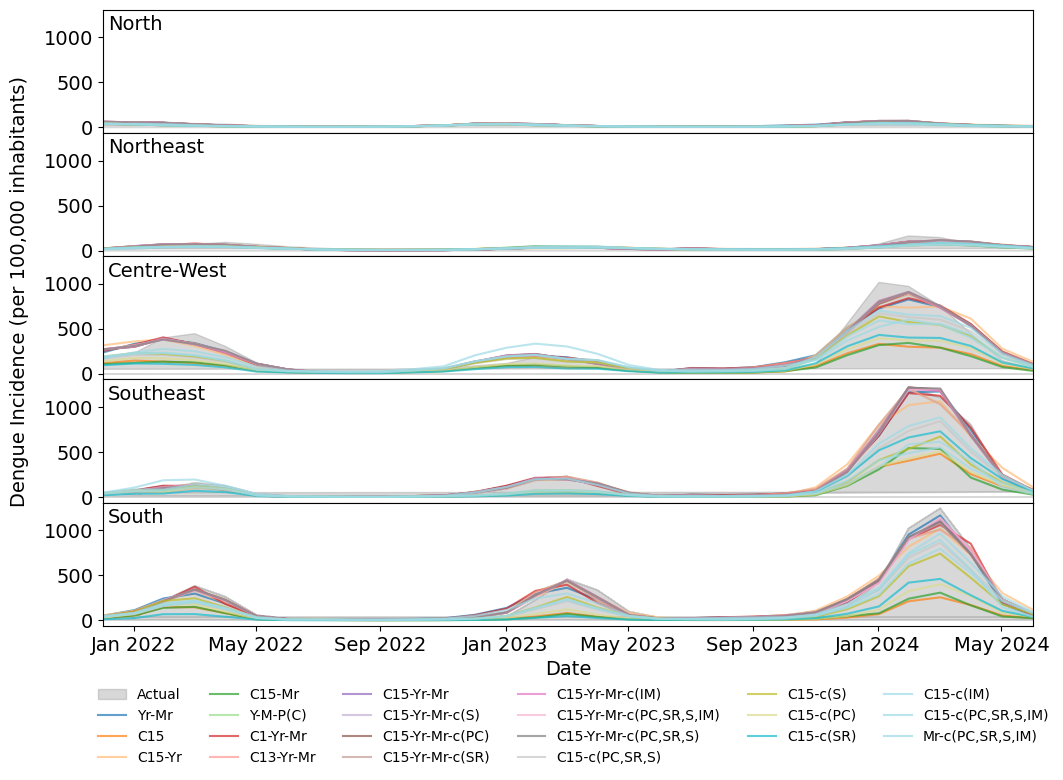


Plot saved as 'model_comparison_by_region_separate_fits.png'


In [7]:
# Create figure with subplots for each region
# Define region order
regions = df['region'].unique()
models = df['model_id'].unique()

region_order = ['North', 'Northeast', 'Centre-West', 'Southeast', 'South']

# Filter to only include regions that exist in the data
regions_to_plot = [r for r in region_order if r in regions]

n_regions = len(regions_to_plot)
n_cols = 1  # 2 columns
n_rows = (n_regions + n_cols - 1) // n_cols  # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0, hspace=0)

axes = axes.flatten() if n_regions > 1 else [axes]

# Define colors for each model - use tab20 to have enough distinct colors
colors = plt.cm.tab20(range(len(models)))
model_colors = dict(zip(models, colors))

# Plot for each region in specified order
for idx, region in enumerate(regions_to_plot):
    ax = axes[idx]
    
    # Filter data for this region
    region_data = df[df['region'] == region].copy()
    
    # Plot actual cases as filled area
    actual_data = region_data[['date_first_symptoms', 'actual_incidence']].drop_duplicates()
    ax.fill_between(actual_data['date_first_symptoms'], 0, actual_data['actual_incidence'], 
                    color='gray', alpha=0.3, label='Actual')
    
    # Plot predicted incidence for each model
    for model in models:
        model_data = region_data[region_data['model_id'] == model]
        if not model_data.empty:
            ax.plot(model_data['date_first_symptoms'], 
                   model_data['predicted_incidence'],
                   linewidth=1.5, label=model, 
                   color=model_colors[model], alpha=0.7)
    
    #ax.set_xlabel('Date', fontsize=11)
    #ax.set_ylabel('Incidence (per 100,000)', fontsize=11)
    # ax.legend(fontsize=8, loc='best')
    #ax.tick_params(axis='x', rotation=45)
    ax.set_xlim([pd.to_datetime('2022-01-01'), df['date_first_symptoms'].max()])
    ax.text(0.005, 0.88, region, transform=ax.transAxes, fontsize=14, va='center', ha='left')

# Remove extra subplots if any
for idx in range(n_regions, len(axes)):
    fig.delaxes(axes[idx])

xticks = pd.date_range(start='2022-01-01', end=df['date_first_symptoms'].max(), freq='4M')

ax.set_xlabel('Date')
ax.text(-0.1, 1, 'Dengue Incidence (per 100,000 inhabitants)', rotation=90, transform=ax.transAxes)
ax.legend(bbox_to_anchor=(1.03, -0.40), frameon=False, fontsize=10, ncols=6)
ax.set_xticks(xticks)
ax.set_xticklabels([x.strftime('%b %Y') for x in xticks])

plt.tight_layout()
plt.savefig('img/model_comparison_by_region_separate_fits.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPlot saved as 'model_comparison_by_region_separate_fits.png'")

In [4]:
def get_bspline_basis(temp_values, bs_basis_df):
    """
    Get B-spline basis functions for given temperature values
    Uses interpolation from the pre-computed dense grid from R
    """
    basis_funcs = []
    for i in range(1, 5):
        col_name = f'basis{i}'
        interp = interp1d(bs_basis_df['temperature'],
                        bs_basis_df[col_name],
                        kind='cubic',
                        fill_value='extrapolate')
        basis_funcs.append(interp(temp_values))
    
    return np.column_stack(basis_funcs)


def get_bspline_derivative(temp_values, bs_basis_df, delta=0.01):
    """
    Get derivative of B-spline basis functions using finite differences
    """
    basis_x = get_bspline_basis(temp_values, bs_basis_df)
    basis_x_delta = get_bspline_basis(temp_values + delta, bs_basis_df)
    
    return (basis_x_delta - basis_x) / delta


def calculate_response(temp_seq, coefficients, vcov, vcov_rownames, bs_basis_df):
    """
    Calculate response curve with standard errors
    """
    n_temps = len(temp_seq)
    n_lags = 5
    
    bs_basis_vals = get_bspline_basis(temp_seq, bs_basis_df)
    design_mat = np.zeros((n_temps, len(vcov_rownames)))
    coef_idx_map = {name: i for i, name in enumerate(vcov_rownames)}
    
    for lag in range(1, n_lags + 1):
        for basis_i in range(1, 5):
            coef_name = f'temp_bs_lag{lag}{basis_i}'
            if coef_name in coef_idx_map:
                idx = coef_idx_map[coef_name]
                design_mat[:, idx] = bs_basis_vals[:, basis_i - 1]
    
    coef_vec = np.array([coefficients.get(name, 0) for name in vcov_rownames])
    y = design_mat @ coef_vec
    se = np.sqrt(np.sum((design_mat @ vcov) * design_mat, axis=1))
    
    return pd.DataFrame({
        'temperature': temp_seq,
        'response': y,
        'se': se
    })


def calculate_marginal_effect(temp_seq, coefficients, vcov, vcov_rownames, bs_basis_df):
    """
    Calculate delta coef (discrete difference per temperature step) with standard errors
    """
    n_temps = len(temp_seq)
    n_lags = 5
    delta_temp = temp_seq[1] - temp_seq[0]
    bs_deriv = get_bspline_derivative(temp_seq, bs_basis_df) * delta_temp
    design_mat = np.zeros((n_temps, len(vcov_rownames)))
    coef_idx_map = {name: i for i, name in enumerate(vcov_rownames)}
    
    for lag in range(1, n_lags + 1):
        for basis_i in range(1, 5):
            coef_name = f'temp_bs_lag{lag}{basis_i}'
            if coef_name in coef_idx_map:
                idx = coef_idx_map[coef_name]
                design_mat[:, idx] = bs_deriv[:, basis_i - 1]
    
    coef_vec = np.array([coefficients.get(name, 0) for name in vcov_rownames])
    y = design_mat @ coef_vec
    se = np.sqrt(np.sum((design_mat @ vcov) * design_mat, axis=1))
    
    return pd.DataFrame({
        'temperature': temp_seq,
        'marginal_effect': y,
        'se': se
    })

print("Helper functions defined")

Helper functions defined


In [5]:
# Define regions
regions = ['National', 'North', 'Northeast', 'Middle_West', 'Southeast', 'South']
region_labels = ['National', 'North', 'Northeast', 'Middle-West', 'Southeast', 'South']
regional_labels = ['North', 'Northeast', 'Middle-West', 'Southeast', 'South']  # Exclude National

# Storage for region data
region_data = {}

print("Loading data for all regions...\n")

for region, label in zip(regions, region_labels):
    print(f"Loading {label}...")
    
    # Load coefficients
    coef_df = pd.read_csv(f'04_coefficients/model_coefficients_{region}.csv')
    coefficients = dict(zip(coef_df['coefficient'], coef_df['value']))
    
    # Load variance-covariance matrix
    vcov_df = pd.read_csv(f'04_coefficients/model_vcov_{region}.csv')
    vcov_rownames = vcov_df['row_name'].values
    vcov = vcov_df.drop(['row_name', 'region'], axis=1).values
    
    # Load metadata
    metadata = pd.read_csv(f'04_coefficients/model_metadata_{region}.csv')
    metadata_dict = dict(zip(metadata['parameter'], metadata['value']))
    
    # Load B-spline basis
    bs_basis = pd.read_csv(f'04_coefficients/bspline_basis_{region}.csv')
    
    # Load temperature data
    temp_data = pd.read_csv(f'04_coefficients/temperature_data_{region}.csv')
    
    # Store all data
    region_data[label] = {
        'coefficients': coefficients,
        'vcov': vcov,
        'vcov_rownames': vcov_rownames,
        'metadata': metadata_dict,
        'bs_basis': bs_basis,
        'temp_data': temp_data
    }
    
    print(f"  Temperature range: {metadata_dict['temp_min']:.1f} to {metadata_dict['temp_max']:.1f}°C")
    print(f"  Mean temperature: {metadata_dict['temp_mean']:.1f}°C")
    print(f"  Pseudo R²: {metadata_dict['pseudo_r2']:.4f}\n")

print(f"Loaded data for {len(region_data)} regions (including National)")

Loading data for all regions...

Loading National...
  Temperature range: 7.5 to 33.5°C
  Mean temperature: 23.2°C
  Pseudo R²: 0.7826

Loading North...
  Temperature range: 21.9 to 33.0°C
  Mean temperature: 26.6°C
  Pseudo R²: 0.6312

Loading Northeast...
  Temperature range: 16.3 to 33.5°C
  Mean temperature: 25.9°C
  Pseudo R²: 0.6432

Loading Middle-West...
  Temperature range: 14.6 to 32.2°C
  Mean temperature: 24.0°C
  Pseudo R²: 0.8273

Loading Southeast...
  Temperature range: 12.1 to 31.1°C
  Mean temperature: 21.8°C
  Pseudo R²: 0.8095

Loading South...
  Temperature range: 7.5 to 29.4°C
  Mean temperature: 19.5°C
  Pseudo R²: 0.8109

Loaded data for 6 regions (including National)


In [6]:
print("Calculating temperature responses for all regions...\n")

# Storage for results
all_responses = {}
all_marginals = {}

for label in region_labels:
    print(f"Processing {label}...")
    
    data = region_data[label]
    
    # Define temperature sequence (FULL RANGE: min to max)
    temp_seq = np.linspace(
        data['metadata']['temp_min'],
        data['metadata']['temp_max'],
        200
    )
    # temp_seq = np.linspace(10, 32, 200)
    
    print(f"  Temperature range: {temp_seq.min():.1f} to {temp_seq.max():.1f}°C")
    
    # Calculate response curve
    response_df = calculate_response(
        temp_seq,
        data['coefficients'],
        data['vcov'],
        data['vcov_rownames'],
        data['bs_basis']
    )
    
    # Calculate marginal effect
    marginal_df = calculate_marginal_effect(
        temp_seq,
        data['coefficients'],
        data['vcov'],
        data['vcov_rownames'],
        data['bs_basis']
    )
    
    # Center response at mean temperature
    temp_mean = data['metadata']['temp_mean']
    idx_mean = np.argmin(np.abs(response_df['temperature'] - temp_mean))
    response_df['response_centered'] = response_df['response'] - response_df['response'].iloc[idx_mean]
    
    # Store results
    all_responses[label] = response_df
    all_marginals[label] = marginal_df
    
    print(f"  Response range: {response_df['response_centered'].min():.2f} to {response_df['response_centered'].max():.2f}")
    print(f"  Marginal effect range: {marginal_df['marginal_effect'].min():.3f} to {marginal_df['marginal_effect'].max():.3f}\n")

print("Calculations complete!")

Calculating temperature responses for all regions...

Processing National...
  Temperature range: 7.5 to 33.5°C
  Response range: -7.97 to 10.94
  Marginal effect range: -0.900 to 0.173

Processing North...
  Temperature range: 21.9 to 33.0°C
  Response range: -10.68 to 0.20
  Marginal effect range: -0.371 to 0.048

Processing Northeast...
  Temperature range: 16.3 to 33.5°C
  Response range: -10.80 to 0.09
  Marginal effect range: -0.068 to 0.209

Processing Middle-West...
  Temperature range: 14.6 to 32.2°C
  Response range: -11.51 to 0.00
  Marginal effect range: -0.027 to 0.243

Processing Southeast...
  Temperature range: 12.1 to 31.1°C
  Response range: -5.16 to 3.34
  Marginal effect range: -0.439 to 0.119

Processing South...
  Temperature range: 7.5 to 29.4°C
  Response range: -2.22 to 4.88
  Marginal effect range: -0.262 to 0.075

Calculations complete!


In [7]:
# Calculate temperature where marginal effect crosses zero (i.e., temperature at maximum response)
print("Calculating temperature at maximum response (where marginal effect = 0) for each region...\n")

max_response_data = []

# Process all regions including National
for label in region_labels:
    marginal_df = all_marginals[label]
    
    # Find where marginal effect crosses zero (changes from positive to negative)
    # This is where the response is at its maximum
    
    # Find sign changes
    sign_changes = np.where(np.diff(np.sign(marginal_df['marginal_effect'])))[0]
    
    # We want the crossing from positive to negative (maximum)
    # Find crossings where marginal effect goes from positive to negative
    max_crossing_idx = None
    max_crossing_temp = None
    
    for idx in sign_changes:
        if marginal_df.loc[idx, 'marginal_effect'] > 0 and marginal_df.loc[idx + 1, 'marginal_effect'] < 0:
            # Linear interpolation to find exact zero crossing
            temp1 = marginal_df.loc[idx, 'temperature']
            temp2 = marginal_df.loc[idx + 1, 'temperature']
            me1 = marginal_df.loc[idx, 'marginal_effect']
            me2 = marginal_df.loc[idx + 1, 'marginal_effect']
            
            # Interpolate: temp = temp1 - me1 * (temp2 - temp1) / (me2 - me1)
            temp_at_zero = temp1 - me1 * (temp2 - temp1) / (me2 - me1)
            
            max_crossing_idx = idx
            max_crossing_temp = temp_at_zero
            break  # Take the first positive-to-negative crossing (the maximum)
    
    if max_crossing_temp is None:
        print(f"{label}: No zero crossing found (marginal effect doesn't change sign)")
        continue
    
    # Calculate confidence interval using delta method
    # At the zero crossing, we need to propagate uncertainty from the marginal effect curve
    # Use the standard errors at the crossing points
    se1 = marginal_df.loc[max_crossing_idx, 'se']
    se2 = marginal_df.loc[max_crossing_idx + 1, 'se']
    
    # Average SE at the crossing
    se_at_crossing = (se1 + se2) / 2
    
    # Calculate temperature uncertainty using the slope of the marginal effect at crossing
    # Delta method: SE(temp) ≈ SE(ME) / |slope of ME|
    temp1 = marginal_df.loc[max_crossing_idx, 'temperature']
    temp2 = marginal_df.loc[max_crossing_idx + 1, 'temperature']
    me1 = marginal_df.loc[max_crossing_idx, 'marginal_effect']
    me2 = marginal_df.loc[max_crossing_idx + 1, 'marginal_effect']
    
    # Slope of marginal effect at crossing
    slope = (me2 - me1) / (temp2 - temp1)
    
    if abs(slope) > 1e-6:  # Avoid division by very small numbers
        # Standard error of temperature at zero crossing
        se_temp = se_at_crossing / abs(slope)
        
        # 95% confidence interval
        temp_ci_lower = max_crossing_temp - 1.96 * se_temp
        temp_ci_upper = max_crossing_temp + 1.96 * se_temp
    else:
        # If slope is nearly zero, use a small default interval
        temp_ci_lower = max_crossing_temp - 1
        temp_ci_upper = max_crossing_temp + 1
    
    max_response_data.append({
        'region': label,
        'temp_at_max': max_crossing_temp,
        'temp_ci_lower': temp_ci_lower,
        'temp_ci_upper': temp_ci_upper,
        'se_temp': se_temp if abs(slope) > 1e-6 else np.nan
    })
    
    print(f"{label}: {max_crossing_temp:.1f}°C (95% CI: [{temp_ci_lower:.1f}, {temp_ci_upper:.1f}])")

max_response_df = pd.DataFrame(max_response_data)

print(max_response_df)

Calculating temperature at maximum response (where marginal effect = 0) for each region...

National: 24.2°C (95% CI: [23.6, 24.8])
North: 24.8°C (95% CI: [21.2, 28.4])
Northeast: 27.1°C (95% CI: [26.3, 27.9])
Middle-West: 24.2°C (95% CI: [23.2, 25.3])
Southeast: 24.7°C (95% CI: [24.2, 25.2])
South: 25.8°C (95% CI: [24.8, 26.8])
        region  temp_at_max  temp_ci_lower  temp_ci_upper   se_temp
0     National    24.155626      23.557237      24.754015  0.305301
1        North    24.837916      21.227548      28.448285  1.842025
2    Northeast    27.102655      26.304623      27.900687  0.407159
3  Middle-West    24.241692      23.213096      25.270287  0.524793
4    Southeast    24.683663      24.183479      25.183847  0.255196
5        South    25.825523      24.827242      26.823804  0.509327



Marginal effects plot saved as marginal_effects_by_region.pdf


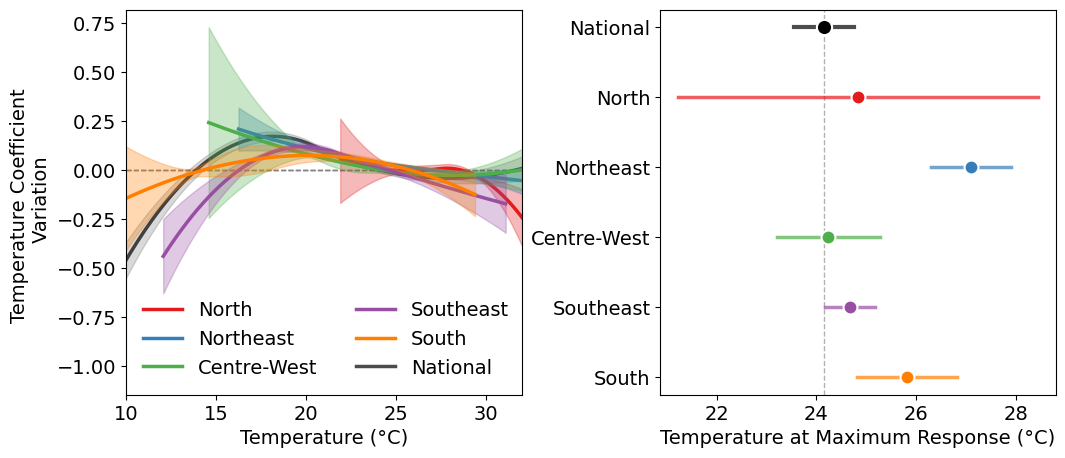

In [8]:
# Define colors for each region
colors = {
    'North': '#e41a1c',
    'Northeast': '#377eb8',
    'Middle-West': '#4daf4a',
    'Southeast': '#984ea3',
    'South': '#ff7f00'
}

# Create a single figure with 5 subplots for marginal effects
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'wspace': 0.35})

# Get national marginal effect data
national_marginal = all_marginals['National']

for i, label in enumerate(regional_labels):
    data = region_data[label]
    marginal_df = all_marginals[label]
    
    
    # Plot REGIONAL marginal effect (foreground)
    ax1.plot(marginal_df['temperature'], marginal_df['marginal_effect'],
           color=colors[label], linewidth=2.5, label=label if label != 'Middle-West' else 'Centre-West', zorder=2)
    
    # Plot regional confidence interval
    ci_lower = marginal_df['marginal_effect'] + norm.ppf(0.025) * marginal_df['se']
    ci_upper = marginal_df['marginal_effect'] + norm.ppf(0.975) * marginal_df['se']
    ax1.fill_between(marginal_df['temperature'], ci_lower, ci_upper,
                   alpha=0.3, color=colors[label], zorder=2)
    
    # Add reference line at zero
    ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1, zorder=0)
  
    # Set x-axis limits to match the region's temperature range
    ax1.set_xlim(10, 32)
    # ax.set_ylim(-10, 5)

    ax1.set_xlabel('Temperature (°C)')
    ax1.set_ylabel('Temperature Coefficient \n Variation')


# Plot NATIONAL marginal effect in BLACK (same curve on all subplots)
ax1.plot(national_marginal['temperature'], national_marginal['marginal_effect'],
        color='black', linewidth=2.5, alpha=0.7, label='National', zorder=1)

# Plot national confidence interval
ci_lower_nat = national_marginal['marginal_effect'] + norm.ppf(0.025) * national_marginal['se']
ci_upper_nat = national_marginal['marginal_effect'] + norm.ppf(0.975) * national_marginal['se']
ax1.fill_between(national_marginal['temperature'], ci_lower_nat, ci_upper_nat, alpha=0.15, color='black', zorder=1)
ax1.legend(frameon=False, ncols=2)

# Reorder for plotting (National at top, then regions from North to South)
plot_order = [
    'National',
    'North',
    'Northeast', 
    'Middle-West', 
    'Southeast', 
    'South',
]
# Only include regions that have data
plot_order = [r for r in plot_order if r in max_response_df['region'].values]
y_positions = {region: i for i, region in enumerate(reversed(plot_order))}

for _, row in max_response_df.iterrows():
    region = row['region']
    y_pos = y_positions[region]
    
    # Determine color
    if region == 'National':
        color = 'black'
        marker_size = 120
        linewidth = 3
    else:
        color = colors[region.split('_')[0] if region.endswith('_nofixed') else region]
        marker_size = 100
        linewidth = 2.5
    
    # Plot confidence interval as horizontal line
    ax2.plot([row['temp_ci_lower'], row['temp_ci_upper']], 
           [y_pos, y_pos],
           color=color, linewidth=linewidth, alpha=0.7, zorder=1)
    
    # Plot point estimate
    ax2.scatter(row['temp_at_max'], y_pos, 
              color=color, s=marker_size, zorder=2, edgecolor='white', linewidth=1.5)

# Formatting
y_positions["Centre-West"] = y_positions.pop("Middle-West")  # Rename for display

ax2.set_yticks(list(y_positions.values()))
ax2.set_yticklabels(list(y_positions.keys()))
ax2.set_xlabel('Temperature at Maximum Response (°C)')
#ax2.set_ylabel('Region')


# Add vertical line at national estimate for reference
if 'National' in max_response_df['region'].values:
    national_temp = max_response_df[max_response_df['region'] == 'National']['temp_at_max'].values[0]
    ax2.axvline(x=national_temp, color='black', linestyle='--', alpha=0.3, linewidth=1, zorder=0)

#ax.legend()
#plt.tight_layout()
plt.savefig('img/marginal_effects_by_region.pdf', dpi=300, bbox_inches='tight')
print("\nMarginal effects plot saved as marginal_effects_by_region.pdf")
plt.show()

In [2]:
models = [
  'Climate(lag 1-5)',
  'Climate(lag 1-5) + Year|region',
  'Climate(lag 1-5) + Month|region',
  'Year + Month + P(Climate)',
  'Climate(lag 1) + Year|region + Month|region',
  'Climate(lag 1-3) + Year|region + Month|region',
  'Climate(lag 1-5) + Year|region + Month|region',
  'Climate(lag 1-5) + Year|region + Month|region + Socio',
  'Climate(lag 1-5) + Year|region + Month|region + PriorCases',
  'Climate(lag 1-5) + Year|region + Month|region + SeroRepla',
  'Climate(lag 1-5) + Year|region + Month|region + Immunity',
  'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity',
  'Climate(lag 1-5) + Socio',
  'Climate(lag 1-5) + PriorCases',
  'Climate(lag 1-5) + SeroRepla',
  'Climate(lag 1-5) + Immunity',
  'Climate(lag 1-5) + PriorCases + SeroRepla + Socio + Immunity',
  'Climate(lag 1-5) + PriorCases + SeroRepla + Socio',
  'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio'  
]

act_all = []
nat_all = []

for model in models:
    print('-' * 60)
    print(f'Model: {model}')
    
    act = pd.read_csv(f'/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue/sensitivity-act/predictions_by_region_{model}.csv', parse_dates=['date_first_symptoms'])
    nat = pd.read_csv(f'/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue/sensitivity-nat/predictions_by_region_{model}.csv', parse_dates=['date_first_symptoms'])
    
    regions = ['North', 'Northeast', 'Middle-West', 'Southeast', 'South']
    
    act = act[act['region'].isin(regions)]
    nat = nat[nat['region'].isin(regions)]
    
    act = act.groupby([
        'model_type', 'region', 'bootstrap_iteration', 'ensemble_member'
    ]).apply(lambda x: pd.Series({
        'predicted_cases': (x['predicted_incidence'] * x['total_population'] / 1e5).sum(),
        'actual_cases': (x['actual_incidence'] * x['total_population'] / 1e5).sum(),
    }), include_groups=False).reset_index()
    
    nat = nat.groupby([
        'model_type', 'region', 'bootstrap_iteration', 'ensemble_member'
    ]).apply(lambda x: pd.Series({
        'predicted_cases': (x['predicted_incidence'] * x['total_population'] / 1e5).sum(),
        'actual_cases': (x['actual_incidence'] * x['total_population'] / 1e5).sum(),
    }), include_groups=False).reset_index()
    
    act = act.groupby(['model_type', 'region', 'bootstrap_iteration']).mean().reset_index()
    nat = nat.groupby(['model_type', 'region', 'bootstrap_iteration']).mean().reset_index()

    act_all.append(act)
    nat_all.append(nat)

act = pd.concat(act_all)
nat = pd.concat(nat_all)

------------------------------------------------------------
Model: Climate(lag 1-5)
------------------------------------------------------------
Model: Climate(lag 1-5) + Year|region
------------------------------------------------------------
Model: Climate(lag 1-5) + Month|region
------------------------------------------------------------
Model: Year + Month + P(Climate)
------------------------------------------------------------
Model: Climate(lag 1) + Year|region + Month|region
------------------------------------------------------------
Model: Climate(lag 1-3) + Year|region + Month|region
------------------------------------------------------------
Model: Climate(lag 1-5) + Year|region + Month|region
------------------------------------------------------------
Model: Climate(lag 1-5) + Year|region + Month|region + Socio
------------------------------------------------------------
Model: Climate(lag 1-5) + Year|region + Month|region + PriorCases
---------------------------------

In [3]:
sorted(nat['model_type'].unique())

['Climate(lag 1) + Year|region + Month|region',
 'Climate(lag 1-3) + Year|region + Month|region',
 'Climate(lag 1-5)',
 'Climate(lag 1-5) + Immunity',
 'Climate(lag 1-5) + Month|region',
 'Climate(lag 1-5) + PriorCases',
 'Climate(lag 1-5) + PriorCases + SeroRepla + Socio',
 'Climate(lag 1-5) + PriorCases + SeroRepla + Socio + Immunity',
 'Climate(lag 1-5) + SeroRepla',
 'Climate(lag 1-5) + Socio',
 'Climate(lag 1-5) + Year|region',
 'Climate(lag 1-5) + Year|region + Month|region',
 'Climate(lag 1-5) + Year|region + Month|region + Immunity',
 'Climate(lag 1-5) + Year|region + Month|region + PriorCases',
 'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio',
 'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity',
 'Climate(lag 1-5) + Year|region + Month|region + SeroRepla',
 'Climate(lag 1-5) + Year|region + Month|region + Socio',
 'Year + Month + P(Climate)']

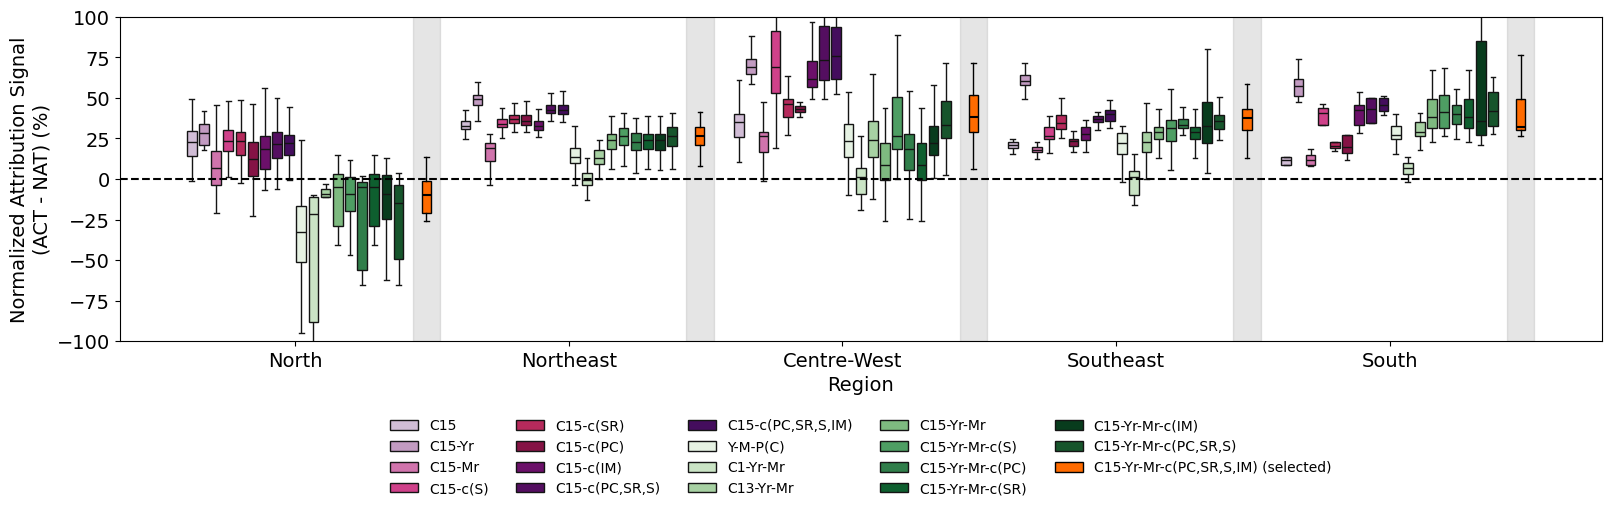

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

model_ids = {
    'Climate(lag 1-5)': 'C15',
    'Climate(lag 1-5) + Month|region': 'C15-Mr',
    'Climate(lag 1-5) + PriorCases': 'C15-c(PC)',
    'Climate(lag 1-5) + SeroRepla': 'C15-c(SR)',
    'Climate(lag 1-5) + Socio': 'C15-c(S)',
    'Climate(lag 1-5) + Immunity': 'C15-c(IM)',
    'Year + Month': 'Y-M',
    'Month|region + PriorCases + SeroRepla + Socio + Immunity': 'Mr-c(PC,SR,S,IM)',
    'Climate(lag 1-5) + PriorCases + SeroRepla + Socio': 'C15-c(PC,SR,S)',
    'Climate(lag 1-5) + PriorCases + SeroRepla + Socio + Immunity': 'C15-c(PC,SR,S,IM)',
    'Year + Month + P(Climate)': 'Y-M-P(C)',
    'Climate(lag 1-5) + Year|region': 'C15-Yr',
    'Climate(lag 1) + Year|region + Month|region': 'C1-Yr-Mr',
    'Climate(lag 1-3) + Year|region + Month|region': 'C13-Yr-Mr',
    'Climate(lag 1-5) + Year|region + Month|region': 'C15-Yr-Mr',
    'Climate(lag 1-5) + Year|region + Month|region + SeroRepla': 'C15-Yr-Mr-c(SR)',
    'Climate(lag 1-5) + Year|region + Month|region + Immunity': 'C15-Yr-Mr-c(IM)',
    'Climate(lag 1-5) + Year|region + Month|region + Socio': 'C15-Yr-Mr-c(S)',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases': 'C15-Yr-Mr-c(PC)',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio': 'C15-Yr-Mr-c(PC,SR,S)',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity': 'C15-Yr-Mr-c(PC,SR,S,IM) (selected)',
}

model_order = {
    "Climate(lag 1-5)": 1,
    "Climate(lag 1-5) + Year|region": 2,
    "Climate(lag 1-5) + Month|region": 3,
    "Climate(lag 1-5) + Socio": 4,
    "Climate(lag 1-5) + SeroRepla": 5,
    "Climate(lag 1-5) + PriorCases": 6,
    "Climate(lag 1-5) + Immunity": 7,
    "Climate(lag 1-5) + PriorCases + SeroRepla + Socio": 8,
    "Climate(lag 1-5) + PriorCases + SeroRepla + Socio + Immunity": 9,
    "Year + Month + P(Climate)": 10,
    "Climate(lag 1) + Year|region + Month|region": 11,
    "Climate(lag 1-3) + Year|region + Month|region": 12,
    "Climate(lag 1-5) + Year|region + Month|region": 13,
    "Climate(lag 1-5) + Year|region + Month|region + Socio": 14,
    "Climate(lag 1-5) + Year|region + Month|region + PriorCases": 15,
    "Climate(lag 1-5) + Year|region + Month|region + SeroRepla": 16,
    "Climate(lag 1-5) + Year|region + Month|region + Immunity": 17,
    "Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio": 18,
}

palette = {
    "C15": "#d4b9da",
    "C15-Yr": "#c994c7",
    "C15-Mr": "#df65b0",
    "C15-c(S)": "#e7298a",
    "C15-c(SR)": "#ce1256",
    "C15-c(PC)": "#980043",
    "C15-c(IM)": "#7a0177",
    "C15-c(PC,SR,S)": "#5e006e",
    "C15-c(PC,SR,S,IM)": "#49006a",
    "Y-M-P(C)": "#e5f5e0",
    "C1-Yr-Mr": "#c7e9c0",
    "C13-Yr-Mr": "#a1d99b",
    "C15-Yr-Mr": "#74c476",
    "C15-Yr-Mr-c(S)": "#41ab5d",
    "C15-Yr-Mr-c(PC)": "#238b45",
    "C15-Yr-Mr-c(SR)": "#006d2c",
    "C15-Yr-Mr-c(IM)": "#00441b",
    "C15-Yr-Mr-c(PC,SR,S)": "#0d5f28",    
    "C15-Yr-Mr-c(PC,SR,S,IM) (selected)": "#FF6B00",
}

plt.rcParams.update({'font.size': 14})

diff = act.set_index(
    ['model_type', 'region', 'bootstrap_iteration']
)[['predicted_cases', 'actual_cases']].rename(
    columns={'predicted_cases': 'act', 'actual_cases': 'fitted'}
).join(
    nat.set_index(
        ['model_type', 'region', 'bootstrap_iteration']
    )[['predicted_cases']].rename(
        columns={'predicted_cases': 'nat'}
    )
).reset_index()

diff['diff'] = 100 * (diff['act'] - diff['nat']) / diff['fitted']
diff = diff[(diff['diff'] > -200) & (diff['diff'] < 200)]
diff = diff.reset_index()
diff['model_order'] = diff['model_type'].map(model_order)
diff['model_id'] = diff['model_type'].map(model_ids)
diff = diff.sort_values('model_order')
diff['region'] = diff['region'].replace({'Middle-West': 'Centre-West'})

region_order = ['North', 'Northeast', 'Centre-West', 'Southeast', 'South']

SELECTED = 'C15-Yr-Mr-c(PC,SR,S,IM) (selected)'

# Split into base models and selected model
palette_base = {k: v for k, v in palette.items() if k != SELECTED}
diff_base     = diff[diff['model_id'] != SELECTED]
diff_selected = diff[diff['model_id'] == SELECTED]

fig, ax = plt.subplots(figsize=(16, 5), constrained_layout=True)

# ── 1. Plot all base models ──────────────────────────────────────────────────
sns.boxplot(
    y='diff',
    x='region',
    hue='model_id',
    data=diff_base,
    ax=ax,
    gap=.2,
    order=region_order,
    hue_order=list(palette_base.keys()),
    palette=palette_base,
    showfliers=False,
)

# ── 2. Plot selected model on top, shifted slightly to the right ─────────────
# dodge=True positions it as an extra hue; we use native_scale + a small
# manual transform via the dodge width calculation instead.
# Easiest: use dodge=True with all hues but hide the others — but that's messy.
# Cleanest: compute x positions manually and use ax.boxplot directly.

n_regions   = len(region_order)
n_base      = len(palette_base)       # 16
total_hues  = len(palette)            # 17
group_width = 0.8                     # seaborn default
box_width   = group_width / total_hues * (1 - 0.2)  # gap=0.2
step        = group_width / total_hues

for r_idx, region in enumerate(region_order):
    region_data = diff_selected[diff_selected['region'] == region]['diff'].dropna()
    if region_data.empty:
        continue

    # x centre of this region group is r_idx (seaborn places groups at 0,1,2,...)
    # position of last hue slot + small extra offset for visual separation
    x_pos = r_idx - group_width / 2 + step * (total_hues - 0.5) + 0.1

    bp = ax.boxplot(
        region_data,
        positions=[x_pos],
        widths=box_width,
        patch_artist=True,
        showfliers=False,
        manage_ticks=False,
        boxprops=dict(facecolor="#FF6B00", color="k"),
        medianprops=dict(color="k", linewidth=1.5),
        whiskerprops=dict(color="k"),
        capprops=dict(color="k"),
    )

    ax.axvspan(x_pos - 0.05, x_pos + 0.05, alpha=0.2, color='grey')

# ── Legend ───────────────────────────────────────────────────────────────────
# Rebuild full legend manually so selected model appears with correct colour
handles, labels = ax.get_legend_handles_labels()
selected_patch = mpatches.Patch(facecolor="#FF6B00", label=SELECTED, edgecolor='k')
handles.append(selected_patch)
labels.append(SELECTED)

ax.legend(
    handles=handles,
    labels=labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.20),
    frameon=False,
    fontsize=10,
    ncols=5,
)

ax.set_ylim([-100, 100])
ax.set_ylabel("Normalized Attribution Signal\n(ACT - NAT) (%)")
ax.set_xlabel("Region")
ax.axhline(0, color='k', ls='--')

plt.savefig('img/figure3_byregion_attribution-signal.pdf', dpi=300, bbox_inches='tight')